# Experiment No. 09

## Title

K-Means Clustering Algorithm to cluster data into multiple groups based on similarity of features.

## Aim

To implement the K-Means Clustering algorithm to partition a given dataset into multiple clusters based on the similarity of their features, and to analyze the resulting groups using an appropriate clustering evaluation method.

## Objectives

1. To understand the basic concept and working principle of K-Means Clustering.
2. To implement the K-Means Clustering algorithm on a given dataset.
3. To group data points into K distinct clusters based on the similarity of their features.
4. To determine suitable cluster centroids and assign each data point to its nearest centroid.
5. To analyze and visualize the formed clusters and interpret the clustering results.

## Relevance

K-Means Clustering is a widely used unsupervised machine learning algorithm for discovering natural groups or patterns within unlabeled data. It is relevant in applications such as customer segmentation, image segmentation, document classification, market analysis, and pattern recognition.

By grouping similar data points into clusters, K-Means helps in understanding the structure and characteristics of complex datasets.

## Dataset Used

### Mall Customers Dataset

The Mall Customers dataset contains customer information that can be used to identify groups of customers based on their characteristics.

The dataset includes features such as customer age, annual income, and spending score. K-Means clustering can be used to discover different customer segments based on these features.

## Step 1: Import Required Libraries

The required Python libraries are imported for data handling, clustering, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## Step 2: Load the Dataset

The Mall Customers dataset is loaded using Pandas. The first five rows are displayed to understand the structure and features of the dataset.

In [2]:
data = pd.read_csv("Mall_Customers.csv")

print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Step 3: Explore the Dataset

The dataset information is checked to understand its size, feature names, data types, and whether any missing values are present.

In [3]:
print("Dataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Step 4: Select Features

For clustering, we select the numerical features that describe the customers. Annual Income and Spending Score are used because they are suitable for identifying customer groups.

In [4]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

print("Selected Features:")
X.head()

Selected Features:


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Step 5: Visualize the Original Data

A scatter plot is created to visualize the relationship between Annual Income and Spending Score before applying clustering.

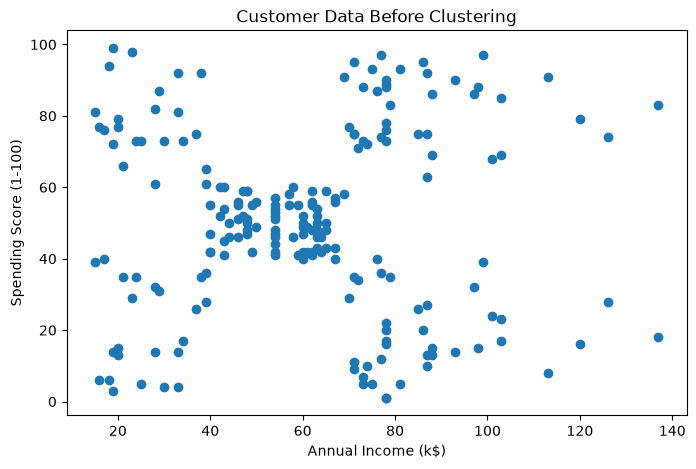

In [5]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data Before Clustering')
plt.show()

## Step 6: Elbow Method

The Elbow Method is used to determine a suitable value of K. We calculate the Within-Cluster Sum of Squares (WCSS), represented by the inertia of K-Means, for different values of K.

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print("WCSS values:")
print(wcss)

C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\c

WCSS values:
[269981.28, 181363.595959596, 106348.37306211119, 73679.78903948837, 44448.45544793371, 37233.81451071001, 30241.343617936585, 25036.41760403398, 21916.794789843727, 20072.070939404006]


C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Step 7: Plot the Elbow Curve

The WCSS values are plotted against the number of clusters. The point where the decrease in WCSS starts slowing down is considered the elbow point and helps us select K.

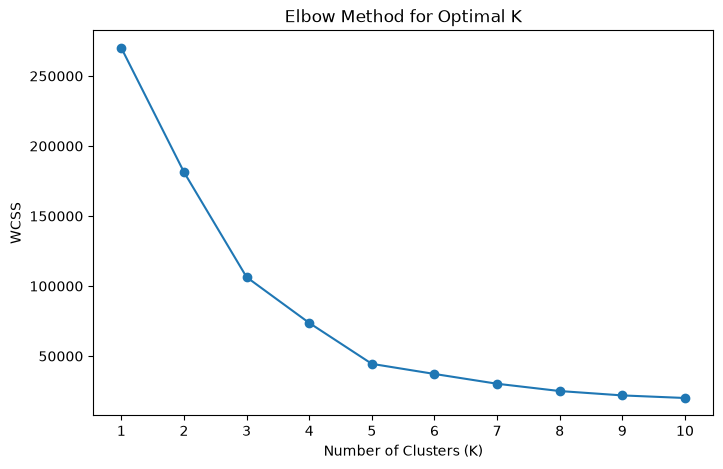

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.show()

## Step 8: Apply K-Means Clustering

Based on the Elbow Method, K-Means is applied with 5 clusters. The algorithm assigns each customer to the nearest cluster and calculates the cluster centroids.

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(X)

print("Cluster Labels:")
print(y_kmeans)

Cluster Labels:
[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


C:\Users\rosha\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Step 9: Add Cluster Labels

The cluster assigned to each customer is added as a new column named Cluster. This allows us to analyze the customer groups.

In [9]:
data['Cluster'] = y_kmeans

print("Dataset with Cluster Labels:")
data.head()

Dataset with Cluster Labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Step 10: Display Cluster Centroids

The centroid of each cluster represents the average Annual Income and Spending Score of the customers belonging to that cluster.

In [10]:
centroids = kmeans.cluster_centers_

print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


## Step 11: Visualize the Clusters

The customer clusters and their centroids are visualized using a scatter plot. Each cluster represents a group of customers with similar Annual Income and Spending Score.

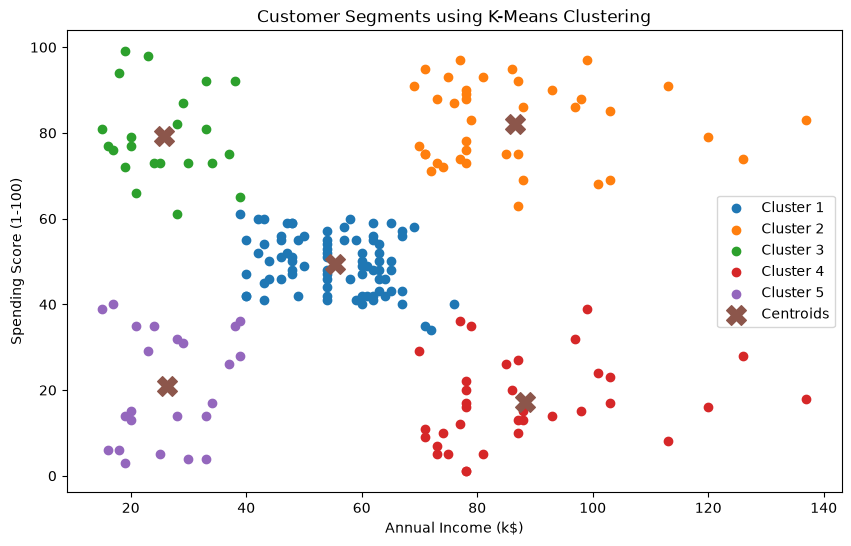

In [11]:
plt.figure(figsize=(10, 6))

for i in range(5):
    plt.scatter(
        X[y_kmeans == i]['Annual Income (k$)'],
        X[y_kmeans == i]['Spending Score (1-100)'],
        label=f'Cluster {i + 1}'
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means Clustering')
plt.legend()
plt.show()

## Step 12: Count Customers in Each Cluster

The number of customers present in each cluster is calculated to understand the size of each customer group.

In [12]:
cluster_counts = data['Cluster'].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## Step 13: Analyze the Clusters

The average Annual Income and Spending Score for each cluster are calculated to understand the characteristics of the customer groups.

In [13]:
cluster_summary = data.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("Cluster-wise Average:")
print(cluster_summary)

Cluster-wise Average:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


## Conclusion

In this experiment, the K-Means Clustering algorithm was successfully implemented on the Mall Customers dataset. The Elbow Method was used to determine a suitable number of clusters. The customers were grouped into five clusters based on Annual Income and Spending Score.

The resulting clusters and their centroids were visualized using a scatter plot. The experiment demonstrated how K-Means can be used to identify meaningful customer segments from unlabeled data based on the similarity of their features.